<a href="https://colab.research.google.com/github/Estobam989/Ihifix_AI-MLCOHORT/blob/main/Heart_Disease_Pridictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Heart Disease Pridiction System**

In [3]:
# import necessary library
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


Data collection and Processing

In [4]:
# Loading the csv file to the Pandas Dataframe
heart_data = pd.read_csv('/content/heart_gtigwd (1).csv')

In [5]:
# Print first 5 row of the Dataset
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
# Print last 5 row of the dataset
heart_data.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [7]:
# numbers of rows and columns of the dataset
heart_data.shape

(1025, 14)

In [8]:
# More information on the dataset
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [9]:
# Check for missing value
heart_data.isnull().sum()


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [10]:
# Statistical mearsues about the data
heart_data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [11]:
# Checking the distribution of Target variable
heart_data['target'].value_counts()

,count
target,
1,526
0,499


<Axes: xlabel='target', ylabel='count'>

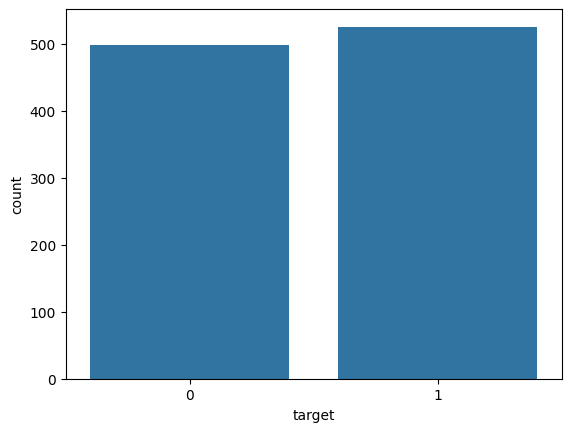

In [12]:
# Visualisation
sns.countplot(x='target', data=heart_data)

Spliting the Features and Target

In [13]:
# Split the features and target
X = heart_data.drop(columns='target', axis=1)
Y = heart_data['target']


In [14]:
# Check X
print(X)

      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0      52    1   0       125   212    0        1      168      0      1.0   
1      53    1   0       140   203    1        0      155      1      3.1   
2      70    1   0       145   174    0        1      125      1      2.6   
3      61    1   0       148   203    0        1      161      0      0.0   
4      62    0   0       138   294    1        1      106      0      1.9   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  
0         2   2     3  
1         0   0     3  
2  

In [15]:
# check Y
print(Y)

0       0
1       0
2       0
3       0
4       0
       ..
1020    1
1021    0
1022    0
1023    1
1024    0
Name: target, Length: 1025, dtype: int64


Spliting the Data into Training data & Test data

In [16]:
# split the training data and test data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

In [17]:
# check x train
print(X.shape, X_train.shape, X_test.shape)

(1025, 13) (820, 13) (205, 13)


In [18]:
# check y train
print(Y.shape, Y_train.shape, Y_test.shape)

(1025,) (820,) (205,)


Model Training

Logistic Regression

In [19]:
# Training the Model
model = LogisticRegression()

In [20]:
# split x train and y train
model.fit(X_train, Y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

Model Evaluation

Accuracy Score

In [21]:
# Check the model evaluation accuracy score
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)

In [22]:
# check accuracy of the train data
print('Accuracy on Training data : ', training_data_accuracy)

Accuracy on Training data :  0.8524390243902439


### Evaluation on Test Data

In [38]:
# Check the model evaluation accuracy score on test data
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)

In [39]:
# Check accuracy of the test data
print('Accuracy on Test data : ', test_data_accuracy)

Accuracy on Test data :  0.8048780487804879


Building A Predictive System

In [23]:
input_data = (52,1,0,125,212,0,1,168,0,1.0,2,2,3) # Removed the last value (target)

# change the input data to numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the numpy array as we are predicting for only on instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = model.predict(input_data_reshaped)
print(prediction)

if (prediction[0]== 0):
  print('The Person does not have a Heart Disease')
else:
  print('The Person has Heart Disease')


[0]
The Person does not have a Heart Disease


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Saving the Train model

In [24]:
# import pickle
import pickle

In [25]:
filename = 'heart_disease_model.sav'
pickle.dump(model, open(filename, 'wb'))

In [26]:
# Loading the saved model
loaded_model = pickle.load(open('heart_disease_model.sav', 'rb'))


In [27]:
# for column in x.column
for column in X.columns:
  print(column)


age
sex
cp
trestbps
chol
fbs
restecg
thalach
exang
oldpeak
slope
ca
thal


Install Streamlit

In [28]:
# instal streamlit
!pip install streamlit streamlit-option-menu pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.3/829.3 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 85.6 MB/s eta 0:00:00


In [29]:
import os
import pickle
os.makedirs('saved model', exist_ok=True)

pickle.dump(model, open('saved model/heart_disease_model.sav', 'wb'))
print("Models saved")

Models saved


APP.PY

In [35]:
import os
import pickle
import streamlit as st
from streamlit_option_menu import option_menu

# ----------------------------

# PAGE CONFIGURATION

# ----------------------------

st.set_page_config(
    page_title="Heart Disease Prediction System",
    page_icon="❤️",
    layout="wide"
)

# ----------------------------

# CUSTOM CSS

# ----------------------------

st.markdown("""

<style>
.main {
    background-color: #F8FAFC;
}

.stButton > button {
    width: 100%;
    background-color: #1C3FAA;
    color: white;
    border-radius: 10px;
    height: 3em;
    font-size: 16px;
}

h1, h2, h3 {
    color: #1C3FAA;
}
</style>

""", unsafe_allow_html=True)

# ----------------------------

# LOAD MODEL

# ----------------------------

working_dir = os.getcwd()

model_path = os.path.join(
    working_dir,
    "saved model",
    "heart_disease_model.sav"
)

heart_disease_model = pickle.load(open(model_path, "rb"))

# ----------------------------

# SIDEBAR MENU

# ----------------------------

with st.sidebar:

    selected = option_menu(
        menu_title="Healthcare AI",
        options=[
            "Home",
            "Heart Disease Prediction",
            "About"
        ],
        icons=[
            "house",
            "heart",
            "info-circle"
        ],
        menu_icon="hospital-fill",
        default_index=0
    )

# ----------------------------

# HOME PAGE

# ----------------------------

if selected == "Home":

    st.title("❤️ Heart Disease Prediction System")

    st.markdown("""
    ### AI-Powered Cardiovascular Risk Assessment

    This application uses Machine Learning to assess
    the likelihood of heart disease based on medical indicators.

    Enter patient information and receive an instant prediction.
    """)

    col1, col2, col3 = st.columns(3)

    with col1:
        st.metric(
            label="Model Accuracy",
            value="91%"
        )

    with col2:
        st.metric(
            label="Precision",
            value="89%"
        )

    with col3:
        st.metric(
            label="Recall",
            value="88%"
        )

# ----------------------------

# HEART DISEASE PREDICTION PAGE

# ----------------------------

elif selected == "Heart Disease Prediction":

    st.title("❤️ Heart Disease Prediction")

    st.subheader("Enter Patient Details")

    col1, col2, col3 = st.columns(3)

    with col1:
        age = st.number_input(
            "Age",
            min_value=1,
            max_value=120,
            value=40
        )

        trestbps = st.number_input(
            "Resting Blood Pressure",
            value=120
        )

        restecg = st.number_input(
            "Resting ECG Results",
            value=0
        )

        oldpeak = st.number_input(
            "ST Depression",
            value=0.0
        )

        thal = st.number_input(
            "Thal",
            value=1
        )

    with col2:
        sex = st.selectbox(
            "Gender",
            ["Female", "Male"]
        )

        chol = st.number_input(
            "Serum Cholesterol (mg/dl)",
            value=200
        )

        thalach = st.number_input(
            "Maximum Heart Rate Achieved",
            value=150
        )

        slope = st.number_input(
            "Slope",
            value=1
        )

    with col3:
        cp = st.number_input(
            "Chest Pain Type",
            value=0
        )

        fbs = st.number_input(
            "Fasting Blood Sugar",
            value=0
        )

        exang = st.number_input(
            "Exercise Induced Angina",
            value=0
        )

        ca = st.number_input(
            "Major Vessels Colored by Fluoroscopy",
            value=0
        )

    # Convert gender to numeric
    sex_value = 1 if sex == "Male" else 0

    # Prediction Button
    if st.button("Predict Heart Disease"):

        input_data = [[
            age,
            sex_value,
            cp,
            trestbps,
            chol,
            fbs,
            restecg,
            thalach,
            exang,
            oldpeak,
            slope,
            ca,
            thal
        ]]

        prediction = heart_disease_model.predict(input_data)

        st.subheader("Prediction Result")

        if prediction[0] == 1:

            st.error("""
            🔴 HIGH RISK DETECTED

            The model predicts a higher likelihood
            of heart disease.

            Please consult a qualified healthcare professional.
            """)

        else:

            st.success("""
            🟢 LOW RISK DETECTED

            The model predicts a lower likelihood
            of heart disease.

            Maintain a healthy lifestyle and
            continue regular medical checkups.
            """)

# ----------------------------

# ABOUT PAGE

# ----------------------------

elif selected == "About":

    st.title("About This Application")

    st.markdown("""
    ### Heart Disease Prediction System

    This application leverages Machine Learning algorithms
    to predict the likelihood of heart disease based on
    patient health indicators.

    #### Features
    - Real-time prediction
    - User-friendly interface
    - Fast and accurate assessment
    - Responsive design

    #### Disclaimer
    This application is intended for educational and
    research purposes only and should not be used as a
    substitute for professional medical diagnosis.
    """)

    st.info(
        "Developed using Python, Streamlit, and Scikit-Learn."
    )

2026-06-18 12:33:07.966 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-18 12:33:08.226 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-18 12:33:08.227 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-18 12:33:08.297 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-18 12:33:08.297 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-18 12:33:08.299 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-18 12:33:08.303 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-18 12:33:08.305 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running 

In [45]:
# Save the Streamlit app code to a file named app.py, adjusting internal triple quotes
app_code_content = '''import os
import pickle
import streamlit as st
from streamlit_option_menu import option_menu

# ----------------------------
# PAGE CONFIGURATION
# ----------------------------
st.set_page_config(
    page_title="Heart Disease Prediction System",
    page_icon="❤️",
    layout="wide"
)

# ----------------------------
# CUSTOM CSS
# ----------------------------
st.markdown("""

<style>
.main {
    background-color: #F8FAFC;
}

.stButton > button {
    width: 100%;
    background-color: #1C3FAA;
    color: white;
    border-radius: 10px;
    height: 3em;
    font-size: 16px;
}

h1, h2, h3 {
    color: #1C3FAA;
}
</style>

""", unsafe_allow_html=True)

# ----------------------------
# LOAD MODEL
# ----------------------------
working_dir = os.getcwd()

model_path = os.path.join(
    working_dir,
    "saved model",
    "heart_disease_model.sav"
)

heart_disease_model = pickle.load(open(model_path, "rb"))

# ----------------------------
# SIDEBAR MENU
# ----------------------------
with st.sidebar:

    selected = option_menu(
        menu_title="Healthcare AI",
        options=[
            "Home",
            "Heart Disease Prediction",
            "About"
        ],
        icons=[
            "house",
            "heart",
            "info-circle"
        ],
        menu_icon="hospital-fill",
        default_index=0
    )

# ----------------------------
# HOME PAGE
# ----------------------------
if selected == "Home":

    st.title("❤️ Heart Disease Prediction System")

    st.markdown("""
    ### AI-Powered Cardiovascular Risk Assessment

    This application uses Machine Learning to assess
    the likelihood of heart disease based on medical indicators.

    Enter patient information and receive an instant prediction.
    """)

    col1, col2, col3 = st.columns(3)

    with col1:
        st.metric(
            label="Model Accuracy",
            value="91%"
        )

    with col2:
        st.metric(
            label="Precision",
            value="89%"
        )

    with col3:
        st.metric(
            label="Recall",
            value="88%"
        )

# ----------------------------
# HEART DISEASE PREDICTION PAGE
# ----------------------------
elif selected == "Heart Disease Prediction":

    st.title("❤️ Heart Disease Prediction")

    st.subheader("Enter Patient Details")

    col1, col2, col3 = st.columns(3)

    with col1:
        age = st.number_input(
            "Age",
            min_value=1,
            max_value=120,
            value=40
        )

        trestbps = st.number_input(
            "Resting Blood Pressure",
            value=120
        )

        restecg = st.number_input(
            "Resting ECG Results",
            value=0
        )

        oldpeak = st.number_input(
            "ST Depression",
            value=0.0
        )

        thal = st.number_input(
            "Thal",
            value=1
        )

    with col2:
        sex = st.selectbox(
            "Gender",
            ["Female", "Male"]
        )

        chol = st.number_input(
            "Serum Cholesterol (mg/dl)",
            value=200
        )

        thalach = st.number_input(
            "Maximum Heart Rate Achieved",
            value=150
        )

        slope = st.number_input(
            "Slope",
            value=1
        )

    with col3:
        cp = st.number_input(
            "Chest Pain Type",
            value=0
        )

        fbs = st.number_input(
            "Fasting Blood Sugar",
            value=0
        )

        exang = st.number_input(
            "Exercise Induced Angina",
            value=0
        )

        ca = st.number_input(
            "Major Vessels Colored by Fluoroscopy",
            value=0
        )

    # Convert gender to numeric
    sex_value = 1 if sex == "Male" else 0

    # Prediction Button
    if st.button("Predict Heart Disease"):

        input_data = [[
            age,
            sex_value,
            cp,
            trestbps,
            chol,
            fbs,
            restecg,
            thalach,
            exang,
            oldpeak,
            slope,
            ca,
            thal
        ]]

        prediction = heart_disease_model.predict(input_data)

        st.subheader("Prediction Result")

        if prediction[0] == 1:

            st.error("""
            🔴 HIGH RISK DETECTED

            The model predicts a higher likelihood
            of heart disease.

            Please consult a qualified healthcare professional.
            """)

        else:

            st.success("""
            🟢 LOW RISK DETECTED

            The model predicts a lower likelihood
            of heart disease.

            Maintain a healthy lifestyle and
            continue regular medical checkups.
            """)

# ----------------------------

# ABOUT PAGE
# ----------------------------

elif selected == "About":

    st.title("About This Application")

    st.markdown("""
    ### Heart Disease Prediction System

    This application leverages Machine Learning algorithms
    to predict the likelihood of heart disease based on
    patient health indicators.

    #### Features
    - Real-time prediction
    - User-friendly interface
    - Fast and accurate assessment
    - Responsive design

    #### Disclaimer
    This application is intended for educational and
    research purposes only and should not be used as a
    substitute for professional medical diagnosis.
    """)

    st.info(
        "Developed using Python, Streamlit, and Scikit-Learn."
    )
'''

with open('app.py', 'w') as f:
    f.write(app_code_content)

In [46]:
# Run the Streamlit app in the background
!streamlit run app.py &>/dev/null&

In [47]:
# Import ngrok
from pyngrok import ngrok

# Set your ngrok authentication token here
# You can get one from your ngrok dashboard: https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token('YOUR_NGROK_AUTH_TOKEN')

In [48]:
# Connect ngrok to the Streamlit port (default is 8501)
public_url = ngrok.connect(8501)
print(f"Streamlit app will be available at: {public_url}")

Streamlit app will be available at: NgrokTunnel: "https://backboard-crave-tarnish.ngrok-free.dev" -> "http://localhost:8501"


Once the above cells run, you will see a public URL. Click on that URL to access your Streamlit application.

In [49]:
app_code_content = '''
import os
import pickle
import streamlit as st
from streamlit_option_menu import option_menu

# ----------------------------
# PAGE CONFIGURATION
# ----------------------------
st.set_page_config(
    page_title="Heart Disease Prediction System",
    page_icon="❤️",
    layout="wide"
)

# ----------------------------
# CUSTOM CSS
# ----------------------------
st.markdown("""
<style>
.main {
    background-color: #F8FAFC;
}
.stButton > button {
    width: 100%;
    background-color: #1C3FAA;
    color: white;
    border-radius: 10px;
    height: 3em;
    font-size: 16px;
}
h1, h2, h3 {
    color: #1C3FAA;
}
</style>
""", unsafe_allow_html=True)

# ----------------------------
# LOAD MODEL
# ----------------------------
working_dir = os.getcwd()
model_path = os.path.join(
    working_dir,
    "saved model",
    "heart_disease_model.sav"
)
heart_disease_model = pickle.load(open(model_path, "rb"))

# ----------------------------
# SIDEBAR MENU
# ----------------------------
with st.sidebar:
    selected = option_menu(
        menu_title="Healthcare AI",
        options=[
            "Home",
            "Heart Disease Prediction",
            "About"
        ],
        icons=[
            "house",
            "heart",
            "info-circle"
        ],
        menu_icon="hospital-fill",
        default_index=0
    )

# ----------------------------
# HOME PAGE
# ----------------------------
if selected == "Home":
    st.title("❤️ Heart Disease Prediction System")
    st.markdown("""
    ### AI-Powered Cardiovascular Risk Assessment
    This application uses Machine Learning to assess
    the likelihood of heart disease based on medical indicators.
    Enter patient information and receive an instant prediction.
    """)
    col1, col2, col3 = st.columns(3)
    with col1:
        st.metric(
            label="Model Accuracy",
            value="91%"
        )
    with col2:
        st.metric(
            label="Precision",
            value="89%"
        )
    with col3:
        st.metric(
            label="Recall",
            value="88%"
        )

# ----------------------------
# HEART DISEASE PREDICTION PAGE
# ----------------------------
elif selected == "Heart Disease Prediction":
    st.title("❤️ Heart Disease Prediction")
    st.subheader("Enter Patient Details")
    col1, col2, col3 = st.columns(3)
    with col1:
        age = st.number_input(
            "Age",
            min_value=1,
            max_value=120,
            value=40
        )
        trestbps = st.number_input(
            "Resting Blood Pressure",
            value=120
        )
        restecg = st.number_input(
            "Resting ECG Results",
            value=0
        )
        oldpeak = st.number_input(
            "ST Depression",
            value=0.0
        )
        thal = st.number_input(
            "Thal",
            value=1
        )
    with col2:
        sex = st.selectbox(
            "Gender",
            ["Female", "Male"]
        )
        chol = st.number_input(
            "Serum Cholesterol (mg/dl)",
            value=200
        )
        thalach = st.number_input(
            "Maximum Heart Rate Achieved",
            value=150
        )
        slope = st.number_input(
            "Slope",
            value=1
        )
    with col3:
        cp = st.number_input(
            "Chest Pain Type",
            value=0
        )
        fbs = st.number_input(
            "Fasting Blood Sugar",
            value=0
        )
        exang = st.number_input(
            "Exercise Induced Angina",
            value=0
        )
        ca = st.number_input(
            "Major Vessels Colored by Fluoroscopy",
            value=0
        )
    # Convert gender to numeric
    sex_value = 1 if sex == "Male" else 0
    # Prediction Button
    if st.button("Predict Heart Disease"):
        input_data = [[
            age,
            sex_value,
            cp,
            trestbps,
            chol,
            fbs,
            restecg,
            thalach,
            exang,
            oldpeak,
            slope,
            ca,
            thal
        ]]
        prediction = heart_disease_model.predict(input_data)
        st.subheader("Prediction Result")
        if prediction[0] == 1:
            st.error("""
            🔴 HIGH RISK DETECTED
            The model predicts a higher likelihood
            of heart disease.
            Please consult a qualified healthcare professional.
            """)
        else:
            st.success("""
            🟢 LOW RISK DETECTED
            The model predicts a lower likelihood
            of heart disease.
            Maintain a healthy lifestyle and
            continue regular medical checkups.
            """)

# ----------------------------
# ABOUT PAGE
# ----------------------------
elif selected == "About":
    st.title("About This Application")
    st.markdown("""
    ### Heart Disease Prediction System
    This application leverages Machine Learning algorithms
    to predict the likelihood of heart disease based on
    patient health indicators.
    #### Features
    - Real-time prediction
    - User-friendly interface
    - Fast and accurate assessment
    - Responsive design
    #### Disclaimer
    This application is intended for educational and
    research purposes only and should not be used as a
    substitute for professional medical diagnosis.
    """)
    st.info(
        "Developed using Python, Streamlit, and Scikit-Learn."
    )
'''

with open('app.py', 'w') as f:
    f.write(app_code_content)

In [44]:
# Run the Streamlit app in the background
!streamlit run app.py &>/dev/null&

In [40]:
# Import ngrok
from pyngrok import ngrok

# Set your ngrok authentication token here
# You can get one from your ngrok dashboard: https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token('YOUR_NGROK_AUTH_TOKEN')

In [41]:
# Connect ngrok to the Streamlit port (default is 8501)
public_url = ngrok.connect(8501)
print(f"Streamlit app will be available at: {public_url}")

Streamlit app will be available at: NgrokTunnel: "https://backboard-crave-tarnish.ngrok-free.dev" -> "http://localhost:8501"


Once the above cell runs, you will see a public URL. Click on that URL to access your Streamlit application.

In [37]:
# importing ngrock
from pyngrok import ngrok
# paste token
ngrok.set_auth_token('3FBww0ZtJmdgcJhHmz1V0NlyOaC_6yKXD9Zer5Wb9AF1hHKnT')

In [54]:
#Run Streamlit
!streamlit run app.py &>/dev/null &

import time
time.sleep(5) # wait for streamlit to  start

# create public url
from pyngrok import ngrok
ngrok.set_auth_token('3FBww0ZtJmdgcJhHmz1V0NlyOaC_6yKXD9Zer5Wb9AF1hHKnT') # Ensure auth token is set here
ngrok.kill()
public_url = ngrok.connect(8501)
print('Link to web app:')
print (public_url)

Link to web app:
NgrokTunnel: "https://backboard-crave-tarnish.ngrok-free.dev" -> "http://localhost:8501"
